### General License: Limiting use of code

-- General License --

MIT License

Copyright (c) [2025] [Nikhil Arora]

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

### Use drop-down arrows on the left of each header/sub-header to expand to the steps/code.

## Task 1: Chatbot Development using Regex

### Target Functionality for chatbot:

An Eliza style chatbot, to hold the following sample conversations:
*   - Person: Where am I?
    - Bot: Next to me.

*   - Person: (How did I come here?) (What brought me here?) (What am I doing here?)
    - Bot: You have been selected by the Matrix.

*   - Person: (who is the matrix?) (Who is this Matrix you talking about?) (What are you talking about?)
    - Bot: It is the future.

*   - Person: (anything else, except bye)
    - Bot: Things will become clearer soon.

- Additional pointers
    * End the conversation when the user inputs phrases indicating end of conversation like "bye", "goodbye", "see you later", "I have to go", etc.
    * Respond with a friendly goodbye message, like "It was nice talking to you. Have a great day!"

### Functions to perform user I/O

- cb_resp(msg): A function that matches input pattern to appropriate response. Here, input and reference patterns are kept in lowercase to avoid case-sensitive issues. “\b” tag is used with reference patterns to limit the boundary on both sides of the input message. “.*” is used with reference patterns which indicates that the expression can be a part of a bigger string.

- cb_conv(): A simulation function is created that starts the conversation and also terminates the conversation if the match condition is met.

In [5]:
import re

# Chatbot response function using regular expressions
def cb_resp(msg):
  responses = {
      r'\b(where am i?)\b': "Next to me.",
      r'\b(how did i come here?|what brought me here?|what am i doing here?)\b': "You have been selected by the Matrix.",
      r'\b(who is the matrix?|who is this matrix you talking about?|what are you talking about?)\b': "It is the future.",
      r'\b(bye)\b|.*(goodbye|see you later|i have to go).*': "It was nice talking to you. Have a great day!"
      # \b is the boundary tag which focuses that there should be nothing before or after this character
      # .* is used indicating there can 0 or more characters before or after previous character
      # All match regexes are kept in lowercase to avoid case-sensitive issues
  }

  for inp, resp in responses.items():
    if re.match(inp, msg.lower()): # converting to lowercase to avoid case-sensitive issues
      return resp # if there ia response match, then this will be returned

  return "Things will become clearer soon." # if nothing matches this will be returned

# Function to simulate a conversation
def cb_conv():
  print("Bot: Welcome! You have arrived! [Type 'bye' to exit]")
  while True:
    inp_msg = input("You: ").strip()
    if re.match(r'\b(bye)\b|.*(goodbye|see you later|i have to go).*', inp_msg.lower()): # To match exit input to terminate the loop
      print("Bot: ", cb_resp(inp_msg))
      break
    print("Bot: ", cb_resp(inp_msg))

### Implementing our chatbot

In [6]:
# Run the conversation simulation function
cb_conv()

Bot: Welcome! You have arrived! [Type 'bye' to exit]
You: Hi
Bot:  Things will become clearer soon.
You: where am i?
Bot:  Next to me.
You: who brought me here?
Bot:  Things will become clearer soon.
You: what am i doing here?
Bot:  You have been selected by the Matrix.
You: who is the matrix?
Bot:  It is the future.
You: sorry i have to go
Bot:  It was nice talking to you. Have a great day!


### Further improvements to explore:

- Solution to problem is very specific to the input, the reference pattern should be made flexible to take care of typo
errors.
- More reference phrases can be included for better results or user can be given some kind of options to choose from as an input.

## Task 2: Author Attribution using the bigram language model

### Bigram description

Authorship Attribution is the problem of identifying the author of a given document by looking at other writings by the same author.

For example, given two novels by William Shakespeare and two by Jane Austen, try to identity the potential author of a sentence that didn't appear in any of the novels given.

One way of tackling this problem is to learn two bigram models, one for Shakespeare and one Austen. Then lookup the probablities of all the bigrams in the new sentence and multiply them to end up with the total liklihood of the sentence. More concretely:
- Training
1.
$$novel\_by\_austen =  \{gram^{austen}_0, gram^{austen}_1,\dots ,gram^{austen}_N\}$$
$$P(gram_i|austen) = \frac{Count(gram^{austen}_i) + 1}{N + V}$$
$$N : \text{Total number of N-grams in the text by Austen}, V : \text{Number of unique n-grams in the text by Austen} $$  

2.
$$novel\_by\_shakespeare =  \{gram^{shakespeare}_0, gram^{shakespeare}_1,\dots ,gram^{shakespeare}_N\}$$
$$P(gram_i|shakespeare) = \frac{Count(gram^{shakespeare}_i) + 1}{N + V}$$
$$N : \text{Total number of N-grams in the text by Shakespeare}, V : \text{Number of unique n-grams in the text by Shakespeare} $$  

- Testing
$$sentence = \{gram_0, gram_1,\dots ,gram_N\}$$

$$P(sentence | shakespeare)\approx\prod_i P(gram_i|shakespeare)$$
$$P(sentence | austen)\approx\prod_i P(gram_i|austen)$$

$$P(author|sentence) = \max(P(sentence | shakespeare), P(sentence | austen))$$

In [ ]:
#pip install nltk

### Importing required Libraries and data.

In [3]:
import nltk
nltk.download("all", quiet=True)

True

In [4]:
from nltk.corpus import gutenberg

In [12]:
gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [6]:
# import libraries needed, read the dataset
import nltk, re, string
from nltk import word_tokenize, sent_tokenize

### Splitting train-test data

In [7]:
sh1 = gutenberg.open('shakespeare-caesar.txt').read()
sh2 = gutenberg.open('shakespeare-hamlet.txt').read()
sh3 = gutenberg.open('shakespeare-macbeth.txt').read()

# shakespeare training data
sh1 = sh1[62:]
sh2 = sh2[55:]

# shakespeare testing data
sh3 = sh3[56:]

In [8]:
au1 = gutenberg.open('austen-emma.txt').read()
au2 = gutenberg.open('austen-persuasion.txt').read()
au3 = gutenberg.open('austen-sense.txt').read()

# austen training data
au1 = au1[28:]
au2 = au2[35:]

# austen testing data
au3 = au3[45:]

### Preprocessing Data

In [9]:
import string
string.punctuation = string.punctuation +'“'+'”'+'-'+'’'+'‘'+'—'
string.punctuation = string.punctuation.replace('.', '')

def preprocess_text(text):
  line_nl_removed = text.replace("\n", " ")      #removes newlines
  line_nl_removed = re.sub(r'\s{2,}', r' ', line_nl_removed) # remove spaces
  line_n1_removed = re.sub(r'VOLUME [MDCLXVI]+ CHAPTER [MDCLXVI]+ ', '', line_nl_removed)
  chars = "".join([char.lower() for char in line_nl_removed if char not in string.punctuation])
  sents = ''
  for sent in sent_tokenize(chars):
    sents += sent.replace(".", " . ")
  sents = re.sub(r'volume [mdclxvi]+ chapter [mdclxvi]+ ', '', sents)

  return sents


In [10]:
#preprocess data
sh_proc = preprocess_text(sh1+sh2)
print(sh_proc[:100])

actus primus . scoena prima . enter flauius murellus and certaine commoners ouer the stage . flauius


In [11]:
#preprocess data
au_proc = preprocess_text(au1+au2)
print(au_proc[:100])

emma woodhouse handsome clever and rich with a comfortable home and happy disposition seemed to unit


In [12]:
# function to further preprocessing the data, to get sentence tokens
def further_prep(dat):
  # splitting the data into sentence
  sent = dat.split(".")
  sent = [t.strip() for t in sent]

  # Extracting tokens into sentences
  sent_tok = []
  for s in sent:
    token = nltk.word_tokenize(s.lower())
    sent_tok.append(token)

  # Appending <s> <s> at the begining of each sentence and <e> at the end of each sentence
  # sent_tok = [['<s>']+['<s>']+s+['<e>'] for s in sent_tok]

  return sent_tok

### Defining Bigram count

In [13]:
# function to define bigram count dictionary
def c_bigrams(sent_tok):
  bi_grams = {}
  for s in sent_tok:
    for t in range(len(s)-1):
      bigram = tuple(s[t:t+2])

      if bigram in bi_grams:
        bi_grams[bigram] += 1
      else:
        bi_grams[bigram] = 1

  return bi_grams

In [14]:
# Defining Probability function
def prob_f(bigram_c, total_c, v_size):
  prob = (bigram_c + 1)/(total_c + v_size)
  return prob

In [15]:
# Defining function to calculate prob of each sentence
def sent_prob(sent, bigram_c, total_c, v_size):
  sent_bigrams = {}
  for t in range(len(sent)-1):
    bigram = tuple(sent[t:t+2])

    if bigram in sent_bigrams:
      sent_bigrams[bigram] += 1
    else:
      sent_bigrams[bigram] = 1

  prob = 1.0
  for bg in sent_bigrams:
    bg_c = bigram_c.get(bg, 0)
    prob *= prob_f(bg_c, total_c, v_size)

  return prob

### Fitting on Training data

In [16]:
# Getting bigrams and bigram count of training Data
sh_bd_train = c_bigrams(further_prep(sh_proc))
au_bd_train = c_bigrams(further_prep(au_proc))

In [17]:
# Getting total counts and vocabulary size for training data sets
sh_tc = sum(sh_bd_train.values())
sh_vs = len(sh_bd_train)
au_tc = sum(sh_bd_train.values())
au_vs = len(sh_bd_train)

### Predicting and Evaluating on test data

In [18]:
# Preprocessing Test Tokens
sh_test = further_prep(preprocess_text(sh3))
au_test = further_prep(preprocess_text(au3))

In [23]:
# Running the model on Shakespeare test set
sh_test_prob = {}

for s in sh_test:
  prob = sent_prob(s, sh_bd_train, sh_tc, sh_vs)
  sh_test_prob[tuple(s)] = prob

# print(sh_test_prob)

# Running the model on Austen test set
au_test_prob = {}

for s in au_test:
  prob = sent_prob(s, au_bd_train, au_tc, au_vs)
  au_test_prob[tuple(s)] = prob

# print(au_test_prob)

In [24]:
# function to take test sentence, to check author
def author_estimate(test_sentence):
  ts = further_prep(preprocess_text(test_sentence))

  sh_prob = 1.0
  au_prob = 1.0

  for s in ts:
    sh_prob *= sent_prob(s, sh_bd_train, sh_tc, sh_vs) # *= combined probability in case of multi-sentence input as per the example given.
    au_prob *= sent_prob(s, au_bd_train, au_tc, au_vs) # *= combined probability in case of multi-sentence input as per the example given.

  print("Probability of the sentence by Shakespeare: ", sh_prob)
  print("Probability of the sentence by Austen: ", au_prob)

  if sh_prob > au_prob:
    print("The most likely author is: Shakespeare")
  else:
    print("The most likely author is: Austen")

In [25]:
# Testing sample example
test_sent = "actus primus . scoena prima . thunder and lightning . enter three witches ."

author_estimate(test_sent)

Probability of the sentence by Shakespeare:  1.6606975950781309e-28
Probability of the sentence by Austen:  4.613048875217032e-30
The most likely author is: Shakespeare


### Further improvements to explore:

- The above model needs more training data as the probabilities on test set is very low.
- Further n_gram models for comparison can be explored as well.

## Task 3: Fake vs Real news classification using Naive Bayes

### Data summary and process description

**Data summary:**  <br>
Data: fake_or_real_news.csv <br>
Columns: index, title, text, label <br>
The `label` column indicates whether the text is 'FAKE' or 'REAL'

**Steps followed:** <br>
1. Loading and inspecting the data using Pandas.
2. Splitting the data into 70% training and 30% testing data.
3. Computing the bag-words on the training data using NLTK library
4. Using the same closed vocabulary in the training data to compute the bag-words of the text in testing data
5. Computing logprior and logliklihood estimates
6. Training a Naive Bayes classifier on the training data using NLTK library
7. Testing the accuracy of the fitted model
8. Computing a confusion matrix on the testing data using a scikit-learn.

### Importing necessary libraries and data

In [ ]:
# pip install pandas

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("https://drive.usercontent.google.com/u/0/uc?id=1P9Pj_YorjQiV1XLdFBuY55bmsR4QKKE9&export=download")

### Inspecting data

In [23]:
#inspecting the data
df['text'].head()

0    Daniel Greenfield, a Shillman Journalism Fello...
1    Google Pinterest Digg Linkedin Reddit Stumbleu...
2    U.S. Secretary of State John F. Kerry said Mon...
3    — Kaydee King (@KaydeeKing) November 9, 2016 T...
4    It's primary day in New York and front-runners...
Name: text, dtype: object

In [24]:
# first column
len(df[df.columns[0]].unique()), len(df)

(6335, 6335)

In [25]:
# Setting index
df = df.set_index(df.columns[0])

In [26]:
df.label

Unnamed: 0
8476     FAKE
10294    FAKE
3608     REAL
10142    FAKE
875      REAL
         ... 
4490     REAL
8062     FAKE
8622     FAKE
4021     REAL
4330     REAL
Name: label, Length: 6335, dtype: object

### Splitting train-test data

In [ ]:
# pip install scikit-learn

In [29]:
# splitting the data using sklearn
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df, test_size = 0.3, random_state=1)

### Preprocessing data

In [30]:
# Preprocessing

# importing required tools and packages
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

# Preprocessing data
## defining stop words
sw = set(stopwords.words('english'))

## Defining preprocess function
def prep(text):
  tokens = word_tokenize(text)
  req_tokens = []
  for w in tokens:
    if (w.isalpha() and w not in sw and w not in string.punctuation):
      req_tokens.append(w.lower())
  # keeping only words with just alphabets and removing punctuation and stopwords
  return req_tokens

### Note: As the dataset description given suggests The label column indicates whether the text is 'FAKE' or 'REAL, we will just focus on text column

## Preprocess text column in training dataset
train_data['prep_tokens'] = train_data['text'].apply(prep)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Defining Bag of words

In [33]:
# Creating bag of words on training dataset using NLTK
from nltk.probability import FreqDist

# To create bag of words collecting all tokens from every text record
train_tokens = []
for tok_list in train_data['prep_tokens']:
  for tok in tok_list:
    train_tokens.append(tok)

fd_train = FreqDist(train_tokens)

In [34]:
# Defining closed vocab
def closed_vocab(freq_dist, count_threshold):
  cw = freq_dist.most_common(count_threshold)
  c_v = [t for t, _ in cw]
  return c_v

In [35]:
# Defining function to create BoW vector
def BoW(tokens_list, closed_vocab):
  unq = set(tokens_list)
  tok = {}
  for w in closed_vocab:
    tok[w] = (w in unq)
  return tok

In [36]:
# Defining training bag of words

len(fd_train) # 54043
# As len > 50,000, we will keep threshold at 2500 as 5%

# defining closed vocab
cl_vocab = closed_vocab(fd_train, 2500)

# bag of words on training set
train_set = [(BoW(tokens, cl_vocab), label) for tokens, label in zip(train_data['prep_tokens'], train_data['label'])]

In [37]:
# Using same closed vocab, defining test bag of words

# Preprocessing test_data
test_data['prep_tokens'] = test_data['text'].apply(prep)

# bag of words on test set
test_set = [(BoW(tokens, cl_vocab), label) for tokens, label in zip(test_data['prep_tokens'], test_data['label'])]

### Computing log prior and log likelihood metrics

In [38]:
# Computing log prior
import math

fake_c = 0
real_c = 0

for _, label in train_set:
  if label == "FAKE":
    fake_c += 1
  else:
    real_c += 1

total_c = len(train_set)

#logprior for real
d_real = math.log(real_c/total_c)
d_fake = math.log(fake_c/total_c)
log_prior = d_real - d_fake

print("logprior: ", log_prior)


logprior:  0.03608871558298843


In [39]:
# Computing loglikelihoods
w_fake_c = FreqDist()
w_real_c = FreqDist()

for t, label in train_set:
  for w, s in t.items():
    if s:
      if label == "FAKE":
        w_fake_c[w] += 1
      else:
        w_real_c[w] += 1

v_size = len(cl_vocab)

# Calculating loglikelihood for each word in closed vocab
lk ={}
for word in cl_vocab:
  f_real = w_real_c.freq(word)
  f_fake = w_fake_c.freq(word)

  p_real = (f_real + 1)/(fake_c + v_size)
  p_fake = (f_fake + 1)/(real_c + v_size)

  lk[word] = math.log(p_real/p_fake)

print(len(lk))

# For example, to get loglikelihood for word "the"
print("loglikelihood for 'the': ", lk['the'])

2500
loglikelihood for 'the':  0.015861901995974245


### Implementing Naive Bayes Classifier and Evaluating using Confusion Matrix

In [42]:
# pip install matplotlib

Accuracy: 0.7716991057338243
Confusion Matrix:
[[805 182]
 [252 662]]


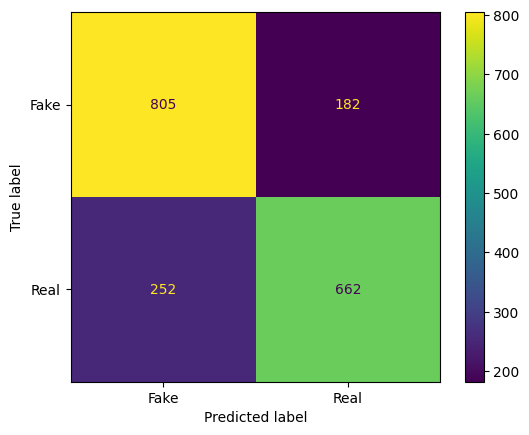

In [43]:
# training Naive Bayes classifier
from nltk import NaiveBayesClassifier

clf = NaiveBayesClassifier.train(train_set)

# Computing the accuracy and confusion matrix on the testing data of the model
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_true = test_data['label']
y_pred = [clf.classify(features) for features, _ in test_set]

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

import matplotlib.pyplot as plt

cm_d = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["Fake", "Real"])

cm_d.plot()
plt.show()

### Further Improvements to explore

- One way to increase accuracy would be training on a larger datasets
- We can try cross-validation for better results

## Task 4: Implementing TF-IDF

### Brief terminology description

The tf–idf is the product of two statistics, term frequency and inverse document frequency. There are various ways for determining the exact values of both statistics, we can use the following formulas.

- Term Frequency
    $$tf_{t,d} = \log_{10}(count(t,d) +1)$$

    $tf_{t,d}$ is the frequency of the word t in the
    document d

-  Inverse Document Frequency
    $$idf_t = \log_{10}(\frac{N}{df_t})$$

    * $N$ is the total number of documents
    * $df_t $ is the number of documents in which term t occurs

-  TF-IDF
    $$tf\text{-}idf_{t,d} = tf_{t,d} \times idf_t $$

### Importing necessary libraries

In [44]:
import numpy as np
import pandas as pd
import math

### Pre-processing data

In [47]:
# Basic Pre-processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
nltk.download('stopwords')
nltk.download('punkt')

# As limited information available, we will limit our pre-processing to tokenization of words, removing puntuation.
# Stemming and stopwords removal added as optional in comments

def prep_t4(st):
  #sw = set(stopwords.words('english')) # If we want to remove stopwords
  #stemmer = PorterStemmer() # For stemming

  # Tokenize
  words = word_tokenize(st.lower())

  # Remove punctuation
  words = [w for w in words if w.isalnum()] # Add "and w not in sw" to remove stopwords

  #words = [stemmer.stem(w) for w in words] # for stemming

  return words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Function to compute tf-idf weights for a document

In [48]:
# Computing tf-idf weights

def compute_tfidf_weights(train_docs):
  '''
  Input arguments:
    train_docs : list of documents, i.e., strings
  Output arguments:
    docs_tf : tf as a DataFrame
    docs_idf : idf as a DataFrame
  '''

  # Intializing empty vocab
  vocab = set()
  # Calculating term frequency
  tf = {}
  for i, doc in enumerate(train_docs):
    d = prep_t4(doc) # Prepeocessing individual doc
    d_tf = {}
    for w in d:
      if w not in d_tf:
        d_tf[w] = 1
      else:
        d_tf[w] += 1

    vocab.update(d_tf.keys()) # Updating vocab to use for calculating df

    for w, c in d_tf.items():
      d_tf[w] = 1 + math.log10(c)
    tf[i] = d_tf

  docs_tf = pd.DataFrame(tf) # To replace NAs with zero, add: ".fillna(0)"

  # Calculating document frequency (df)
  n_doc = len(train_docs) # Total number of documents
  # vocab = set(w for d in train_docs for w in d) # Creating a set of words from all the documents to calculate df

  df = {}
  for w in vocab:
    counter = 0
    for d in train_docs:
      if w in prep_t4(d):
        counter += 1
    df[w] = counter

  # Calculating idf
  idf = {}
  for w, df in df.items():
    idf[w] = math.log10(n_doc/df)

  docs_idf = pd.DataFrame.from_dict(idf, orient='index', columns=['idf'])

  return docs_tf, docs_idf

In [49]:
# Sample testing
train_docs = [
    "First string is important.",
    "This is the second important.",
    "And this string is the third string.",
    "Is third string important?",
]

docs_tf, docs_idf = compute_tfidf_weights(train_docs)
print("Term Frequency (TF) DataFrame:")
print(docs_tf)
print("\nInverse Document Frequency (IDF) DataFrame:")
print(docs_idf)

Term Frequency (TF) DataFrame:
             0    1        2    3
first      1.0  NaN      NaN  NaN
string     1.0  NaN  1.30103  1.0
is         1.0  1.0  1.00000  1.0
important  1.0  1.0      NaN  1.0
this       NaN  1.0  1.00000  NaN
the        NaN  1.0  1.00000  NaN
second     NaN  1.0      NaN  NaN
and        NaN  NaN  1.00000  NaN
third      NaN  NaN  1.00000  1.0

Inverse Document Frequency (IDF) DataFrame:
                idf
this       0.301030
the        0.301030
first      0.602060
second     0.602060
and        0.602060
third      0.301030
string     0.124939
is         0.000000
important  0.124939


### Function to compute tf-idf for a word

In [50]:
# Computing tf-idf

def word_tfidf_vector(word, tf_df, idf_df):
  '''
    Input arguments:
      word : a query string
      tf_tf : tf as a DataFrame
      tf_idf : idf as a DataFrame
    Output arguments:
      tf_idf_value : a numpy array of dimension 1xN
  '''
  tf_idf_value = tf_df.loc[word] * idf_df.loc[word]['idf']
  tf_idf_value = tf_idf_value.to_numpy().reshape(1, -1) # Converting to required array format
  return tf_idf_value

In [51]:
# Sample testing
word = "string"
tf_idf_value = word_tfidf_vector(word, docs_tf, docs_idf)
print(f"\nTF-IDF vector for the word '{word}': {tf_idf_value}")


TF-IDF vector for the word 'string': [[0.12493874        nan 0.16254904 0.12493874]]


### Further improvements to explore

- Final computation function for tf-idf can be modified to take just word and the reference strings as inputs rather than tf, idf data frames. This way we can reference the weights function within this function.

## Task 5: Developing sentiment classifier for twitter data: Comparing Traditional and NN based models

### Targeted description

- Implementing a sentiment classifier based on Twitter data to analyse the sentiments of COVID-19 tweets.  

- Train and test multiple classification model using necessary libraries with the features being sentence embeddings of tweets.

- Reporting the accuracy and F1 score (micro- and macro-averaged) for multiple classifier and compare the differences.

**Tweet representation** <br>
After necessary pre-processing of the tweets, convert the words into their embeddings, then take the mean of all the word vectors in a tweet to end up with a single vector representing each tweet. The tweet vector is then used for sentiment classification.

In the process of finding the embeddings for each word,  out-of-vocabulary words are ignored.

**Classifier choice** <br>
Implementing the following two classifiers:
* Tradition classification model - Logistic Regression
* Classifier based on a neural network based model - MLP Classifier

### Loading dataset and necessary libraries

In [1]:
# Load Dataset
import pandas as pd
train_data_url = "https://drive.google.com/uc?export=download&id=19JmVSOZ85vikn5aKna97aL5LM8KtG3T7"
test_data_url = "https://drive.google.com/uc?export=download&id=19EnwRfr6q5lzVB_UpJlGOG3IxgDhYVgP"

df_train = pd.read_csv(train_data_url, encoding='latin-1')[["OriginalTweet","Sentiment"]].rename(columns={'OriginalTweet': 'tweet', 'Sentiment': 'label'})
df_test = pd.read_csv(test_data_url, encoding='latin-1')[["OriginalTweet","Sentiment"]].rename(columns={'OriginalTweet': 'tweet', 'Sentiment': 'label'})

df_test

,tweet,label
0,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,When I couldn't find hand sanitizer at Fred Me...,Positive
2,Find out how you can protect yourself and love...,Extremely Positive
3,#Panic buying hits #NewYork City as anxious sh...,Negative
4,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral
...,...,...
3793,Meanwhile In A Supermarket in Israel -- People...,Positive
3794,Did you panic buy a lot of non-perishable item...,Negative
3795,Asst Prof of Economics @cconces was on @NBCPhi...,Neutral
3796,Gov need to do somethings instead of biar je r...,Extremely Negative


In [2]:
import re
import string
import numpy as np

### Preprocessing data

In [3]:
# Preprocess Function
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer
nltk.download('stopwords')
nltk.download('twitter_samples')

def prep_t5(tweet):
  stemmer = PorterStemmer()
  stopwords_english = stopwords.words('english')

  # remove tweet specific symbols, texts, etc.
  tweet = re.sub(r'\$\w*', '', tweet)
  tweet = re.sub(r'^RT[\s]+', '', tweet)
  tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet)
  tweet = re.sub(r'#', '', tweet)

  # Tokenize tweets
  tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
  tweet_tokens = tokenizer.tokenize(tweet)

  tweets_clean = []
  for word in tweet_tokens:
      if (word not in stopwords_english and word not in string.punctuation):
          stem_word = stemmer.stem(word)
          tweets_clean.append(stem_word)

  return tweets_clean

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


In [4]:
# Apply preprocessing on training and test dataset
# Adding a new column "token" to have a list of words (tokens) for each tweet.
df_train['token'] = df_train['tweet'].apply(prep_t5)
df_test['token'] = df_test['tweet'].apply(prep_t5)

df_test.head(5)

,tweet,label,token
0,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative,"[trend, new, yorker, encount, empti, supermark..."
1,When I couldn't find hand sanitizer at Fred Me...,Positive,"[find, hand, sanit, fred, meyer, turn, amazon,..."
2,Find out how you can protect yourself and love...,Extremely Positive,"[find, protect, love, one, coronaviru]"
3,#Panic buying hits #NewYork City as anxious sh...,Negative,"[panic, buy, hit, newyork, citi, anxiou, shopp..."
4,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral,"[toiletpap, dunnypap, coronaviru, coronavirusa..."


### Defining embeddings

In [5]:
# Defining embeddings function
# mean to get a single vector and ignore if out of vocabulary
def tw_embed(embeddings_data, tokens):
    emb = []
    for t in tokens:
        if t in embeddings_data:
            emb.append(embeddings_data[t])

    # Check if embeddings are available
    if emb:
        # Calculate the mean of embeddings
        mean_emb = np.mean(emb, axis=0)
        return mean_emb
    else:
        # Return None if no embeddings are available for any word
        return None

Note: using the following embedding: glove-twiiter-100

In [57]:
# Used the following command to shortlist the embedding:
# list(zip(list(api.info()['models'].keys()) , [api.info()['models'][key]['description'] for key in api.info()['models'].keys()]))

In [ ]:
# pip install gensim

In [9]:
# Takes about 3-4 mins to load
import gensim.downloader as api
embeddings_data = api.load('glove-twitter-100')

[==================================================] 100.0% 387.1/387.1MB downloaded


In [10]:
# Creating embeddings for both train and test data
df_train['embeddings'] = df_train['token'].apply(lambda x: tw_embed(embeddings_data, x))
df_test['embeddings'] = df_test['token'].apply(lambda x: tw_embed(embeddings_data, x))

In [11]:
df_test.head(5)

,tweet,label,token,embeddings
0,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative,"[trend, new, yorker, encount, empti, supermark...","[-0.28030002, -0.0941343, 0.091636784, -0.1488..."
1,When I couldn't find hand sanitizer at Fred Me...,Positive,"[find, hand, sanit, fred, meyer, turn, amazon,...","[-0.15828623, -0.12677208, 0.05969735, -0.1491..."
2,Find out how you can protect yourself and love...,Extremely Positive,"[find, protect, love, one, coronaviru]","[-0.037032507, 0.0448825, -0.024827503, 0.5917..."
3,#Panic buying hits #NewYork City as anxious sh...,Negative,"[panic, buy, hit, newyork, citi, anxiou, shopp...","[-0.045175783, 0.24405201, -0.0966856, -0.2300..."
4,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral,"[toiletpap, dunnypap, coronaviru, coronavirusa...","[-0.264195, -0.0365947, 0.18740863, -0.1248476..."


### Preparing training and testing data

In [12]:
# Defining X and y variable for test and train data set
X_train = np.vstack(df_train['embeddings'].dropna())
y_train = df_train.dropna()['label']
X_test = np.vstack(df_test['embeddings'].dropna())
y_test = df_test.dropna()['label']

In [13]:
# Encoding target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

### Fitting data using `LogisticRegression` and `MLPClassifier`

In [14]:
# Performing logistic Regression
from sklearn.linear_model import LogisticRegression
# Defining classifier
log_cf = LogisticRegression(max_iter = 1000) # For comparison maximum iterations are kept constant for both classifiers
# Fitting the model on training set
log_cf.fit(X_train, y_train_encoded)

LogisticRegression(max_iter=1000)

In [15]:
# Performing MLP classifier
from sklearn.neural_network import MLPClassifier
# Defining classifier
mlp_cf = MLPClassifier(hidden_layer_sizes = (100, ), max_iter=1000) # For comparison maximum iterations are kept constant for both classifiers
# Fitting the model on training set
mlp_cf.fit(X_train, y_train_encoded)

MLPClassifier(max_iter=1000)

### Predicting evaluating the models

In [16]:
# Classifying on test sets
log_yhat = log_cf.predict(X_test)
mlp_yhat = mlp_cf.predict(X_test)

# Decoding predictions
log_yhat = label_encoder.inverse_transform(log_yhat)
mlp_yhat = label_encoder.inverse_transform(mlp_yhat)

In [17]:
# Defining Evaluation function to compute Accuracy and F1 statistic
from sklearn.metrics import accuracy_score, f1_score

def eval_cf(y_true, y_hat):
  accuracy = accuracy_score(y_true, y_hat)
  micro_f1 = f1_score(y_true, y_hat, average = "micro")
  macro_f1 = f1_score(y_true, y_hat, average = "macro")
  return {'Accuracy': accuracy, 'F1 Score (Micro)': micro_f1, 'F1 Score (Macro)': macro_f1}

In [18]:
# Comparing classifier
log_eval = eval_cf(y_test, log_yhat)
mlp_eval = eval_cf(y_test, mlp_yhat)
print("Evaluation metrics for Logistic Regression Classifier: ")
print(log_eval)
print("Evaluation metrics for MLP Classifier: ")
print(mlp_eval)
print("\n")

# Is MLP Classifier better than Logistic Regression Classfier?
print("Accuracy for MLP better than Logistic Regression: ", mlp_eval['Accuracy']>log_eval['Accuracy'])
print("F1 Score (Micro) for MLP better than Logistic Regression: ", mlp_eval['F1 Score (Micro)']>log_eval['F1 Score (Micro)'])
print("F1 Score (Macro) for MLP better than Logistic Regression: ", mlp_eval['F1 Score (Macro)']>log_eval['F1 Score (Macro)'])

Evaluation metrics for Logistic Regression Classifier: 
{'Accuracy': 0.39082278481012656, 'F1 Score (Micro)': 0.39082278481012656, 'F1 Score (Macro)': 0.38190765924913556}
Evaluation metrics for MLP Classifier: 
{'Accuracy': 0.41482067510548526, 'F1 Score (Micro)': 0.41482067510548526, 'F1 Score (Macro)': 0.42203289435756963}


Accuracy for MLP better than Logistic Regression:  True
F1 Score (Micro) for MLP better than Logistic Regression:  True
F1 Score (Macro) for MLP better than Logistic Regression:  True


### Interpretation and Further improvements

**Based on the Evaluation results following can be interpreted:**
* Accuracy and F1 Scores for both the models approximate around 0.40, which suggests further fine tuning is required to better fit the model and improve the results.
* In terms of both evaluation metrics, MLP classifier produces slightly better results than Logistic Regression classifier.
* For Logistic Regression Classifier, micro F1 Score is better than macro F1 Score, but it is vice versa for MLP Classifier.



## Task 6: Using POS-tagging for classification

### Task Description

Implementing a simple pragram that receive interactions in the form of a sentence and return:
* A tuple of (command, object) (eg. (Grab, book)) if the sentence is a command
* None if the sentence is not a command

Considering the following EXAMPLE sentences:

* Commands:
  * Grab the book
  * Fetch the ball
  * Open the jar
  

* Not commands:
  * Hey, how is it going?
  * How is your day today?
  * Do you like the weather?

This list is not exhaustive

### Using `en_core_web_sm` from spacy as POS tagger

In [ ]:
# pip install spacy
# !python -m spacy download en_core_web_sm

In [24]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [25]:
def prep_t6(sentence):
  sent = nlp(sentence)
  tagged_tokens = [(token.text, token.pos_) for token in sent]

  return tagged_tokens

### Defining Classification function and Sample Testing

**Classification Logic:** <br>
General structure of a command is a verb token followed by a determiner (optional) followed by a noun token. So verb is classified as command and noun as object in a tuple for an input sentence where the general sequence is:  
        Verb <-> Determiner (optional) <-> Noun

So, filtering logic is as follows:


* 1st filter is to filter out sentences ending "?" and "!"
* Then look for Verb <-> Determiner (optional) <-> Noun structure to identify and classify (command, object)

In [27]:
# Defining Classification function

def command_cf(sentence):
  # Filter out sentence ending "?" and "!"
  if sentence[-1] in ['!', '?']:
    return None

  # tokenize and tag sentence
  tok_tag = prep_t6(sentence)

  # Initialize empty variables
  cmd = None
  obj = None

  # Iterate over tagged-token
  for i in range(len(tok_tag) - 1):
    # look for verb
    if tok_tag[i][1].startswith('VERB'):
      cmd = tok_tag[i][0]

      # check if next token is noun or determiner <-> noun
      if i+1 < len(tok_tag) and tok_tag[i+1][1].startswith('NOUN'):
        obj = tok_tag[i+1][0]
        return (cmd, obj)
      elif i+1 < len(tok_tag) and tok_tag[i+1][1].startswith('DET'):
        if i+2 < len(tok_tag) and tok_tag[i+2][1].startswith('NOUN'):
          obj = tok_tag[i+2][0]
          return (cmd, obj)

  return None

In [28]:
# Sample Testing
sentences = [
    "Grab the book",
    "Fetch the ball",
    "Open the jar",
    "Hey, how is it going?",
    "How is your day today?",
    "Do you like the weather?"
]

print("(Command, Object) for commands and None for not commands")
for sent in sentences:
  print(sent, ": ", command_cf(sent))

(Command, Object) for commands and None for not commands
Grab the book :  ('Grab', 'book')
Fetch the ball :  ('Fetch', 'ball')
Open the jar :  ('Open', 'jar')
Hey, how is it going? :  None
How is your day today? :  None
Do you like the weather? :  None


### Alternate Solution: Using `average_perceptron_tagger` from nltk

In [29]:
# Using part-of-speech tagging from nltk
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet = True)
nltk.download('averaged_perceptron_tagger', quiet = True)

# Function to tokenize and tag
def prep_t6a(sentence):
  tokens = word_tokenize(sentence)
  tagged_tokens = nltk.pos_tag(tokens)

  return tagged_tokens

# Defining Classification function

def command_cf2(sentence):
  # Filter out sentence ending "?" and "!"
  if sentence[-1] in ['!', '?']:
    return None

  # tokenize and tag sentence
  tok_tag = prep_t6a(sentence)

  # Initialize empty variables
  cmd = None
  obj = None

  # Iterate over tagged-token
  for i in range(len(tok_tag) - 1):
    # look for verb
    if tok_tag[i][1].startswith('VB'):
      cmd = tok_tag[i][0]

      # check if next token is noun or determiner <-> noun
      if i+1 < len(tok_tag) and tok_tag[i+1][1].startswith('NN'):
        obj = tok_tag[i+1][0]
        return (cmd, obj)
      elif i+1 < len(tok_tag) and tok_tag[i+1][1].startswith('DT'):
        if i+2 < len(tok_tag) and tok_tag[i+2][1].startswith('NN'):
          obj = tok_tag[i+2][0]
          return (cmd, obj)

  return None

# Sample Testing
sentences = [
    "Grab the book",
    "Fetch the ball",
    "Open the jar",
    "Hey, how is it going?",
    "How is your day today?",
    "Do you like the weather?"
]

print("(Command, Object) for commands and None for not commands")
for sent in sentences:
  print(sent, ": ", command_cf2(sent))

(Command, Object) for commands and None for not commands
Grab the book :  ('Grab', 'book')
Fetch the ball :  ('Fetch', 'ball')
Open the jar :  ('Open', 'jar')
Hey, how is it going? :  None
How is your day today? :  None
Do you like the weather? :  None
